In [1]:
pip install pandas numpy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import sqlite3
import numpy as np
import pandas as pd

#Seed for synthetic data
np.random.seed(42)

#defining firms, regions and quarters
firms = ["Firm A", "Firm B", "Firm C", "Firm D", "Firm E"]
regions = ["North", "South", "East", "West"]
quarters = [f"2024-Q{q}" for q in range (1,5)] + [f"2025-Q{q}" for q in range (1,5)]

data = []
transaction_id = 1

# Generating quarterly values/ cost shock over time to simulate inflation affecting input cost. Weighting firms based on market power which helps to model:
#1 Quantity Sold, 2 Input cost per unit 3: Selling Price (where larger firmd can dictate prices more)
for q in quarters:
   #Macro input cost shock with exogenous shock over time
    base_cost = 10 + (quarters.index(q) * 0.75) + np.random.normal(0,0.5)

    for r in regions:
        for f in firms:
             #Generating market power for firms, scaling for each firm for simplicity
            firm_weight = (firms.index(f) + 1) * 0.2

            #Demand function (with lower bound)
            units_sold = int(np.random.normal(500 * firm_weight, 50))
            units_sold = max(50, units_sold)

            #Firm specific wholesale cost function
            unit_cost = max(5.0, base_cost + np.random.normal(0,0.8))

            #Retail Pricing function, depending on firm market power  and random market noise (location, promotions etc)
            unit_price = unit_cost * (1.2 + (firm_weight * 0.1)) + np.random.normal(0,0.5)

            #Dictionary for store records
            data.append(
                {
                    "transaction_id": transaction_id,
                    "firm_id" : f,
                    "region_id" : r,
                    "quarter_date" : q,
                    "units_sold" : units_sold,
                    "unit_price" : round(unit_price, 2),
                    "unit_cost" : round(unit_cost, 2)
                }
            )
            transaction_id+=1

#Turning dictionary into Pandas DataFrame
df = pd.DataFrame(data)

#Save database to SQLlite
conn = sqlite3.connect("market_data.db")
df.to_sql("transactions", conn, if_exists="replace", index=False)
conn.close()

print(
    f"Success! 'market_data.db' created with {len(df)} records."
)
                    
            

Success! 'market_data.db' created with 160 records.


In [3]:
conn = sqlite3.connect("market_data.db")

#calculating market shares per firm
sql_market_share = """
WITH regional_totals AS (
    SELECT
        quarter_date,
        region_id,
        firm_id,
        units_sold * unit_price AS revenue,
        units_sold * (unit_price - unit_cost) AS profit,
        SUM (units_sold * unit_price) OVER (PARTITION BY quarter_date, region_id) AS total_regional_revenue
    FROM transactions
)
SELECT
    quarter_date,
    region_id,
    firm_id,
    ROUND(revenue, 2) AS total_revenue,
    ROUND(profit, 2) AS total_profit,
    ROUND(revenue/total_regional_revenue, 4) AS market_share
FROM regional_totals
ORDER BY quarter_date, region_id, firm_id;
"""

df_market_share = pd.read_sql_query(sql_market_share, conn)

#Displaying DataFrame to verify resutls
df_market_share.head(10)

,quarter_date,region_id,firm_id,total_revenue,total_profit,market_share
0,2024-Q1,East,Firm A,2296.32,330.24,0.1224
1,2024-Q1,East,Firm B,2795.60,561.53,0.1491
2,2024-Q1,East,Firm C,2357.34,500.96,0.1257
3,2024-Q1,East,Firm D,5772.64,1242.60,0.3078
4,2024-Q1,East,Firm E,5532.12,1142.24,0.2950
5,2024-Q1,North,Firm A,1292.70,291.09,0.0742
6,2024-Q1,North,Firm B,2494.76,603.48,0.1432
7,2024-Q1,North,Firm C,4295.98,959.92,0.2465
8,2024-Q1,North,Firm D,4797.76,1082.88,0.2753
9,2024-Q1,North,Firm E,4545.00,961.52,0.2608


In [4]:
#HHi calculation using SQL, using window functions and CTEs
sql_hhi = """
WITH firm_shares AS (
    SELECT
        quarter_date,
        region_id,
        firm_id,
        (SUM(units_sold * unit_price) * 100.0 / 
         SUM(SUM(units_sold * unit_price)) OVER (PARTITION BY quarter_date, region_id)) AS share_percentage
    FROM transactions
    GROUP BY quarter_date, region_id, firm_id
)
SELECT
    quarter_date,
    region_id,
    ROUND(SUM(share_percentage * share_percentage), 0) AS hhi_index
FROM firm_shares
GROUP BY quarter_date, region_id
ORDER BY quarter_date, region_id;
"""

df_hhi = pd.read_sql_query(sql_hhi, conn)

#Displaying DataFrame to verify resuls
df_hhi.head(10)

,quarter_date,region_id,hhi_index
0,2024-Q1,East,2348.0
1,2024-Q1,North,2306.0
2,2024-Q1,South,2685.0
3,2024-Q1,West,2783.0
4,2024-Q2,East,2807.0
5,2024-Q2,North,2509.0
6,2024-Q2,South,2647.0
7,2024-Q2,West,2675.0
8,2024-Q3,East,2438.0
9,2024-Q3,North,2838.0


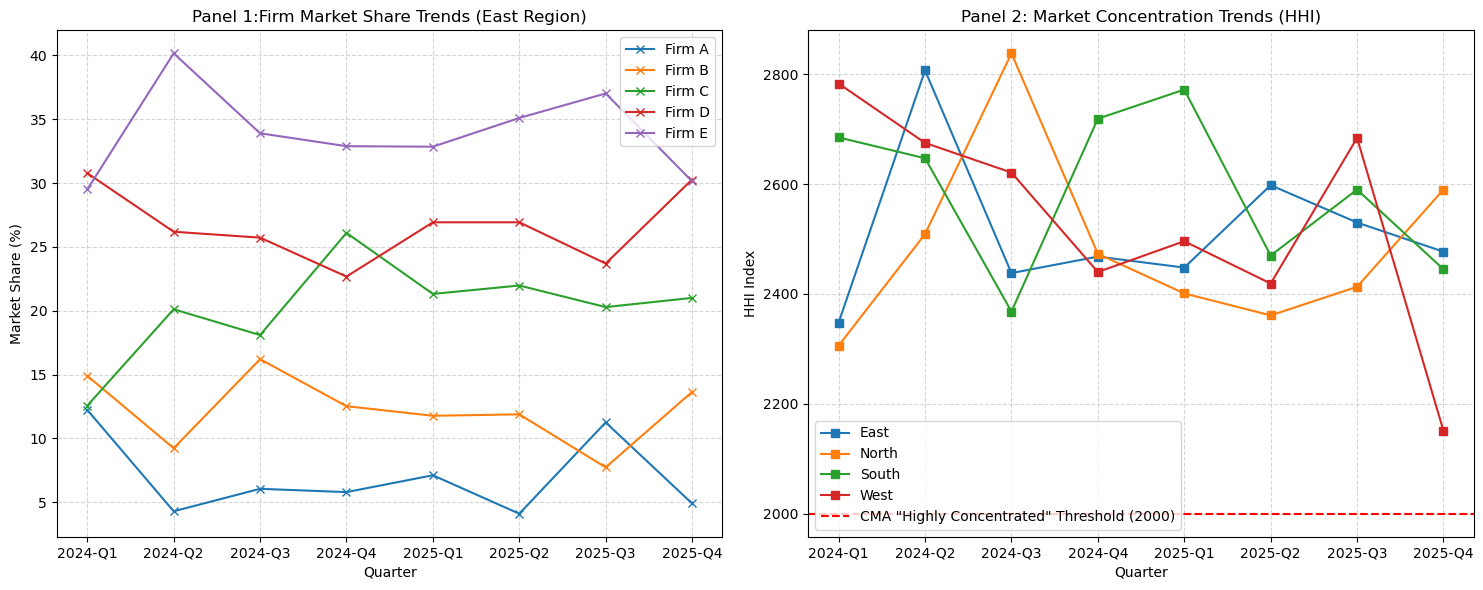

In [5]:
import matplotlib.pyplot as plt

#Creating 2 panel plot
fig, (ax1, ax2) = plt.subplots(1,2, figsize = (15,6))

#Panel 1, individual firms
df_east = df_market_share[df_market_share['region_id'] == 'East']

for firm in df_east['firm_id'].unique():
    firm_data = df_east[df_east['firm_id'] == firm]
#Comvert market share into percentage
    ax1.plot(firm_data["quarter_date"], firm_data["market_share"] * 100, marker = 'x', label=firm)

ax1.set_title("Panel 1:Firm Market Share Trends (East Region)")
ax1.set_xlabel("Quarter")
ax1.set_ylabel("Market Share (%)")
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend()

#Panel 2: Regional HHI Trends vs CMA market threshold
for region in df_hhi["region_id"].unique():
    region_data = df_hhi[df_hhi["region_id"] == region]
    ax2.plot(region_data["quarter_date"], region_data["hhi_index"], marker = "s", label=region)

#Adding CMA threshold for high concentration
ax2.axhline(2000, color="red", linestyle="--", linewidth=1.5, label='CMA "Highly Concentrated" Threshold (2000)')

ax2.set_title("Panel 2: Market Concentration Trends (HHI)")
ax2.set_xlabel("Quarter")
ax2.set_ylabel("HHI Index")
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend()

plt.tight_layout()
plt.show()

## Empirical Findings

### 1. Regional Market Structure
* **Persistent High Concentration** Across all four UK regions. The calculated **Herfindahl-Hirschman Index (HHI)** consistently remains above **2000**, indicated by the red line located on Panel 2. HHI fluctuated between **2150 and 2850** over all 8 quarters.
*  **Application to Regulatory Framework** Under **UK Competition and Markets Authority (CMA)** guidelines, a HHI score exceeding 2000 classifies these markets as **Highly Concentrated**, signalling potential market issues, such as excess market power, high barriers to entry, and consumer welfare loss.

### 2. Microeconomic Firm Dynamics (using East Region)
* **Duopoly Dominance:** **Firm D** and **Firm E** hold nearly **60% of total regional revenue** combined.
* **Firms A, B and C** display a lower market share, remaining below **Firms D and E** (exceeding Q4-2024), highlighting a potential lack in scale required to challenge the market leaders.

---

### Hypothesis for Policy Simulation
Because unconstrained firm dynamics in this market reveal persistent concentration levels, **Notebook 2 ("02_policy_simulation.ipnyb")** will model a counterfactual **regulatory price cap** to test whether constraints on the market can rebalance market shares, lowering regional HHI scores.